# Dependencies importing

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import psycopg2
import datetime
import seaborn as sns

import sys
sys.path.append('custom_modules')

import prepare_original_data_for_db as data_prep
import visualize_data as data_visual

from matplotlib import ticker
from IPython.display import display

In [2]:
# paths for files with original data
# pah for fgfg 
# fsdf sdfg dfgdfthtgbf 
RUN_NUM = 1
path_to_data_file = f'data/Original data/Run{RUN_NUM}/run{RUN_NUM}_WM32_data.csv' 
path_to_defects_file = f'data/Original data/Run{RUN_NUM}/run{RUN_NUM}_WM32_defects.csv' 
path_to_pipe_file = f'data/Original data/Run{RUN_NUM}/run{RUN_NUM}_WM32_pipe.csv' 

# Data reading

In [3]:
# data reading
data_df = data_prep.get_df_from_data_file(path_to_data_file)
defects_df = data_prep.get_df_from_defects_file(path_to_defects_file)
pipe_df = data_prep.get_df_from_pipe_file(path_to_pipe_file)

# Data preprocess

## Output ML model data preprocess

In [4]:
# defects depths mask creation from defects_df from data from data_df

# create base zeros dataframe with size like data_df
temp_pipe_df = pd.DataFrame(np.zeros((data_df.shape[0], data_df.shape[1])))

# read line-by-line defects_df
# get defects location and mark by ones
for row_name in defects_df.index.values.tolist():

    # get defect properties
    row_min = int(defects_df.loc[row_name].loc['row_min'])
    row_max = int(defects_df.loc[row_name].loc['row_max'])
    detector_min = int(defects_df.loc[row_name].loc['detector_min'])   
    detector_max = int(defects_df.loc[row_name].loc['detector_max'])
    defect_depth = defects_df.loc[row_name].loc['fea_depth']

    #defect_depth = 1
    
    # mark defect location in base dataframe
    if (detector_min < detector_max):
        temp_pipe_df.iloc[row_min:row_max+1,detector_min:detector_max+1] = defect_depth
        continue

    temp_pipe_df.iloc[row_min:row_max+1,detector_min:data_df.shape[1]] = defect_depth
    temp_pipe_df.iloc[row_min:row_max+1,0:detector_max+1] = defect_depth

    pipe_df = temp_pipe_df

In [5]:
# draw a 2D map from a 2D dataframe
# shift > 0 roll df along columns right
# shift < 0 roll df along columns left
def draw_2D_map(df: pd.DataFrame, 
                title: str,
                shift: int = 0, 
                xlabel: str = 'Номер датчика', 
                ylabel: str = 'Номер измерения',
                xlabel_num = 10,
                ylabel_num = 8):

    xlabel_num += 1
    
    with plt.style.context('dark_background'):
        fig, ax = plt.subplots()

        # decorate
        fig.set_figwidth(18)
        fig.set_figheight(8)
        fig.patch.set_alpha(0.0)
        ax.invert_yaxis()
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        # set text parameters
        ax.set_title(title, fontsize=25) 
        ax.set_xlabel(xlabel, fontsize=20) 
        ax.set_ylabel(ylabel, fontsize=20) 
        ax.tick_params(axis='both', which='both', labelsize = 20)
        
        # shift dataframe along columns
        if shift < 0:
            df = pd.concat([df.iloc[:,abs(shift):],
                            df.iloc[:,:abs(shift)]], axis=1)
        elif shift > 0:
            df = pd.concat([df.iloc[:,(df.shape[1]-shift):],
                            df.iloc[:,:(df.shape[1]-shift)]], axis=1)
            
            
        # draw map
        ax.pcolormesh(df)

        # create new labels
        # create y labels
        new_y_locs = new_y_labels = np.linspace(0, df.shape[0], ylabel_num).astype(int)
        plt.yticks(new_y_locs, new_y_labels)
        
        # create x labels
        cols = np.array(df.columns.values.tolist()).astype(int)
        step = df.shape[1]/(xlabel_num-1)

        # set essential labels (left number, border number, right number)
        if shift < 0:
            new_x_labels = np.array([abs(shift), df.shape[1]-1, abs(shift)-1])
        elif shift > 0:
            new_x_labels = np.array([(df.shape[1]-shift), df.shape[1]-1, (df.shape[1]-shift)-1])
        else:
            new_x_labels = new_x_locs = np.linspace(0, df.shape[1], xlabel_num).astype(int)

        # add number between essential ones
        if shift != 0:
            # how many numbers add left of border one
            left = int(abs(new_x_labels[0] - new_x_labels[1]) // step)
            # how many numbers add right of border one
            right = int(new_x_labels[2] // step)
            
            new_x_labels = np.concatenate([np.array([new_x_labels[0]]),
                                   np.linspace(new_x_labels[0], new_x_labels[1], left).astype(int)[1:-1],
                                   np.array([new_x_labels[1]]),
                                   np.linspace(0, new_x_labels[2], right).astype(int)[1:-1],
                                   np.array([new_x_labels[2]])],axis=0)

            # find locs of each label number in columns list
            new_x_locs = np.array([]).astype(int)
            for item in new_x_labels:
                new_x_locs = np.append(new_x_locs, np.where(cols == item)[0][0])

            new_x_labels = new_x_labels.astype(str)
            new_x_labels[new_x_labels == '399'] = '399/0'
    
        plt.xticks(new_x_locs, new_x_labels)
    
    plt.show()

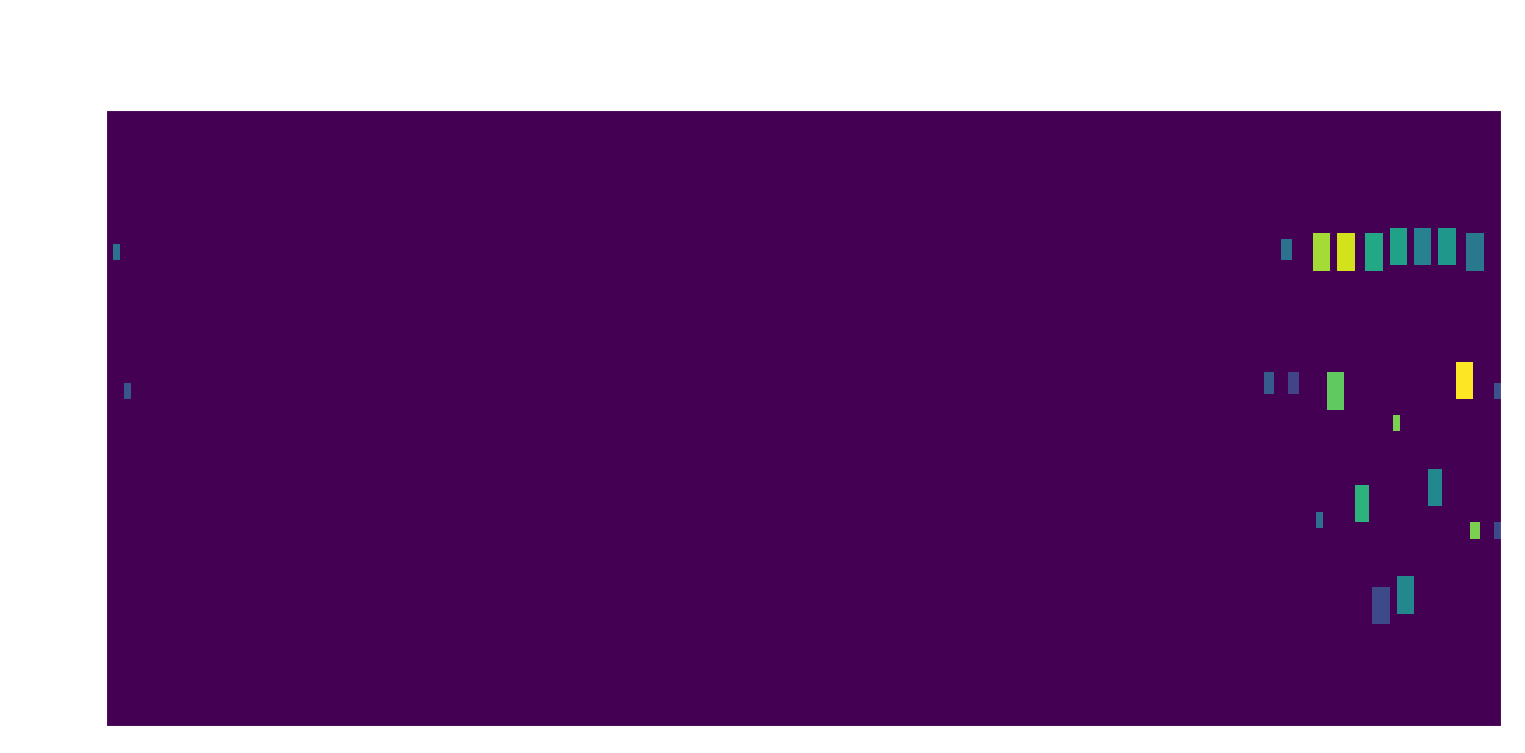

In [6]:
data_visual.draw_defects_map(df=pipe_df, 
            title=f'Развернутая карта дефектов файл {RUN_NUM}', 
            shift=-30)